In [3]:
# ==============================================================================
#                      COMPLETE EMPLOYEE ANALYSIS SCRIPT
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. IMPORTS AND DATA LOADING
# ------------------------------------------------------------------------------
import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns
import math
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Install prince for potential future use (optional, but good practice if needed)
!pip install prince -q

In [20]:
# Load the dataset
try:
    data_original = pd.read_csv('Uncleaned_employees_final_dataset.csv')
except FileNotFoundError:
    print("Error: The dataset file was not found. Please ensure 'Uncleaned_employees_final_dataset (1).csv' is in the correct directory.")
    exit() # Exit the script if the file is not found

# Display basic information and the first few rows
print("--- Initial Data Overview ---")
data_original.info()

--- Initial Data Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17417 entries, 0 to 17416
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            17417 non-null  int64  
 1   department             17417 non-null  object 
 2   region                 17417 non-null  object 
 3   education              16646 non-null  object 
 4   gender                 17417 non-null  object 
 5   recruitment_channel    17417 non-null  object 
 6   no_of_trainings        17417 non-null  int64  
 7   age                    17417 non-null  int64  
 8   previous_year_rating   16054 non-null  float64
 9   length_of_service      17417 non-null  int64  
 10  KPIs_met_more_than_80  17417 non-null  int64  
 11  awards_won             17417 non-null  int64  
 12  avg_training_score     17417 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 1.7+ MB


In [21]:
data_original.drop(columns=["region"],axis=1)

,employee_id,department,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,Bachelors,m,sourcing,1,30,4.0,7,0,0,61
...,...,...,...,...,...,...,...,...,...,...,...,...
17412,64573,Technology,Bachelors,f,referred,2,30,5.0,6,1,0,81
17413,49584,HR,Bachelors,m,other,1,33,1.0,9,0,0,51
17414,49584,HR,Bachelors,m,other,1,33,1.0,9,0,0,51
17415,49584,HR,Bachelors,m,other,1,33,1.0,9,0,0,51


In [22]:
data=data_original

In [23]:
data=data.dropna()
(data.isnull().sum()/len(data))*100

employee_id              0.0
department               0.0
region                   0.0
education                0.0
gender                   0.0
recruitment_channel      0.0
no_of_trainings          0.0
age                      0.0
previous_year_rating     0.0
length_of_service        0.0
KPIs_met_more_than_80    0.0
awards_won               0.0
avg_training_score       0.0
dtype: float64

In [24]:
# ------------------------------------------------------------------------------
# 2. INITIAL SETUP FOR EXPLORATORY DATA ANALYSIS (EDA)
# ------------------------------------------------------------------------------
# Create a copy for analysis to keep the original data intact
eda = data_original.copy()

# Define column types for easier analysis
colonnes_quantitatives = ["no_of_trainings", "age", "previous_year_rating", "length_of_service", "avg_training_score"]
colonnes_qualitatives = ["department","education", "gender", "recruitment_channel", "KPIs_met_more_than_80", "awards_won"]

# Convert binary columns to boolean for more intuitive analysis in plots
eda[["KPIs_met_more_than_80", "awards_won"]] = eda[["KPIs_met_more_than_80", "awards_won"]].astype(bool)
print("\nEDA setup complete. Ready for visualization.")


EDA setup complete. Ready for visualization.


In [25]:
print("\n--- Data Head ---")
data_original.head()



--- Data Head ---


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61


In [26]:
eda[colonnes_qualitatives].describe()

,department,education,gender,recruitment_channel,KPIs_met_more_than_80,awards_won
count,17417,16646,17417,17417,17417,17417
unique,9,3,2,3,2,2
top,Sales & Marketing,Bachelors,m,other,False,False
freq,5458,11519,12314,9751,11167,17010


In [27]:
eda[colonnes_quantitatives].describe()

,no_of_trainings,age,previous_year_rating,length_of_service,avg_training_score
count,17417.000000,17417.000000,16054.000000,17417.000000,17417.000000
mean,1.250732,34.807774,3.345459,5.801860,63.176322
std,0.595692,7.694046,1.265386,4.175533,13.418179
min,1.000000,20.000000,1.000000,1.000000,39.000000
25%,1.000000,29.000000,3.000000,3.000000,51.000000
50%,1.000000,33.000000,3.000000,5.000000,60.000000
75%,1.000000,39.000000,4.000000,7.000000,75.000000
max,9.000000,60.000000,5.000000,34.000000,99.000000



--- Generating Histograms for Quantitative Variables ---


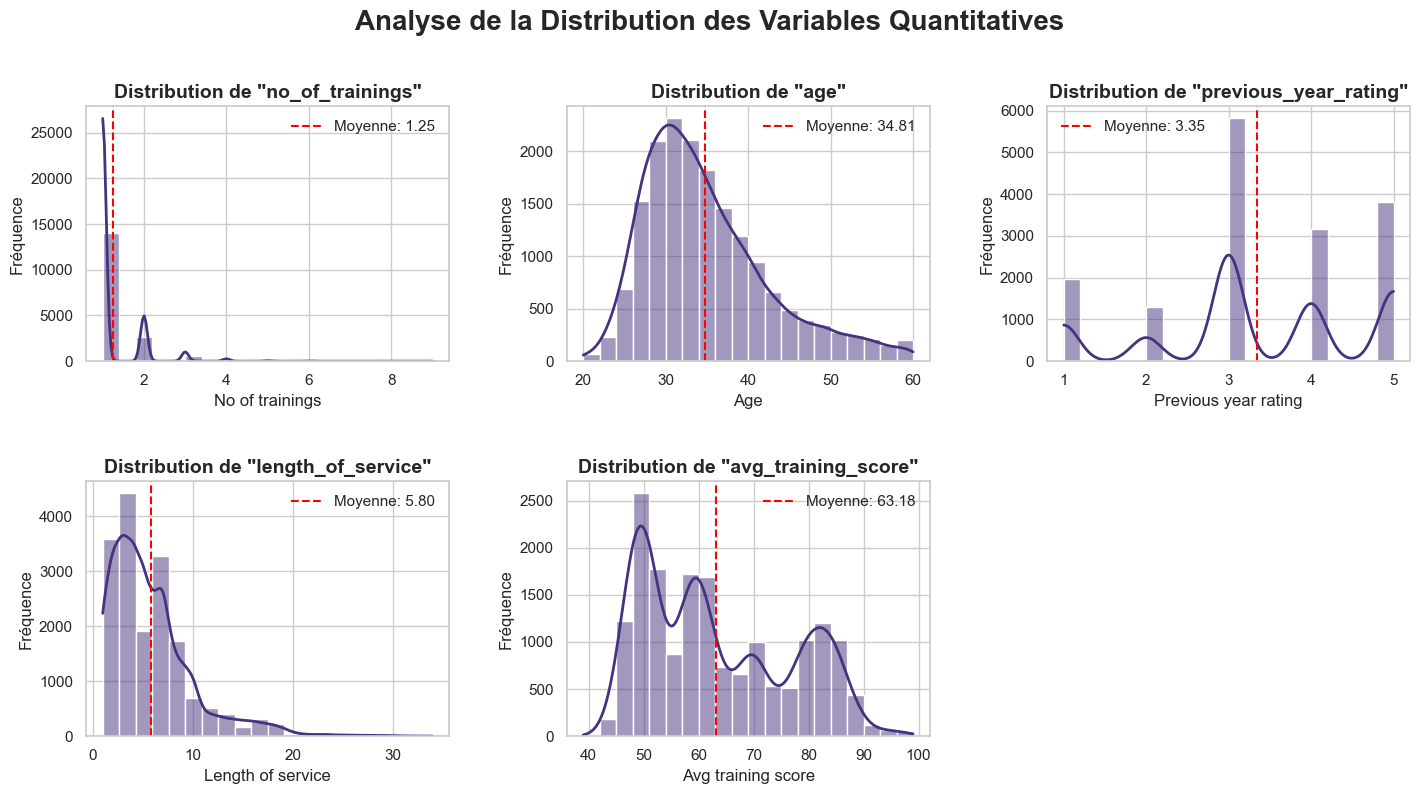

In [28]:
# 3. EDA - DISTRIBUTION OF QUANTITATIVE VARIABLES (HISTOGRAMS)
# ------------------------------------------------------------------------------
print("\n--- Generating Histograms for Quantitative Variables ---")
sns.set_theme(style="whitegrid", palette="viridis")
num_plots = len(colonnes_quantitatives)
num_cols = 3
num_rows = math.ceil(num_plots / num_cols)
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 4))
axes = axes.flatten()
for i, col in enumerate(colonnes_quantitatives):
    ax = axes[i]
    sns.histplot(data=eda, x=col, kde=True, ax=ax, bins=20, line_kws={'linewidth': 2})
    mean_val = eda[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', label=f'Moyenne: {mean_val:.2f}')
    ax.set_title(f'Distribution de "{col}"', fontsize=14, fontweight='bold')
    ax.set_xlabel(col.replace('_', ' ').capitalize(), fontsize=12)
    ax.set_ylabel('Fréquence', fontsize=12)
    ax.legend()
for j in range(num_plots, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout(pad=3.0)
fig.suptitle('Analyse de la Distribution des Variables Quantitatives', fontsize=20, fontweight='bold', y=1.03)
plt.show()

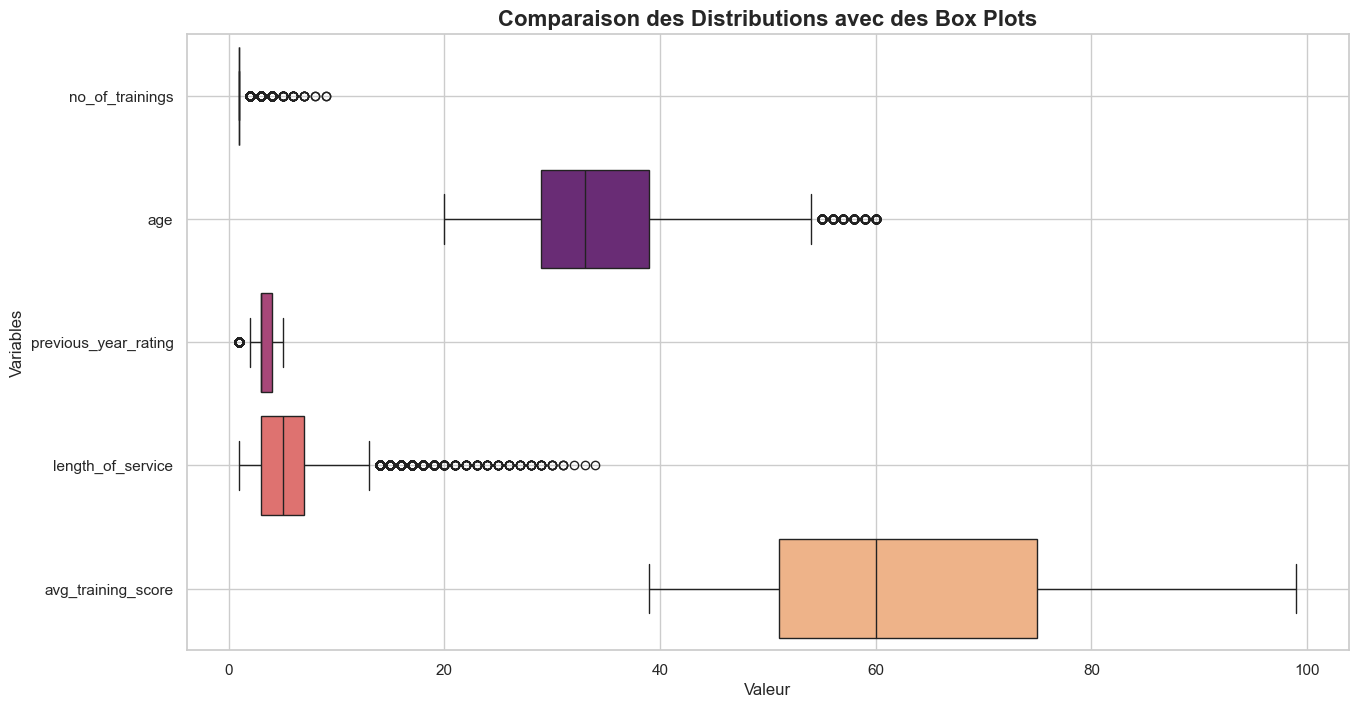

In [29]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=eda[colonnes_quantitatives], orient='h', palette='magma')


plt.title('Comparaison des Distributions avec des Box Plots', fontsize=16, fontweight='bold')
plt.xlabel('Valeur', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.grid(True)
plt.show()


--- Generating Count Plots for Qualitative Variables ---


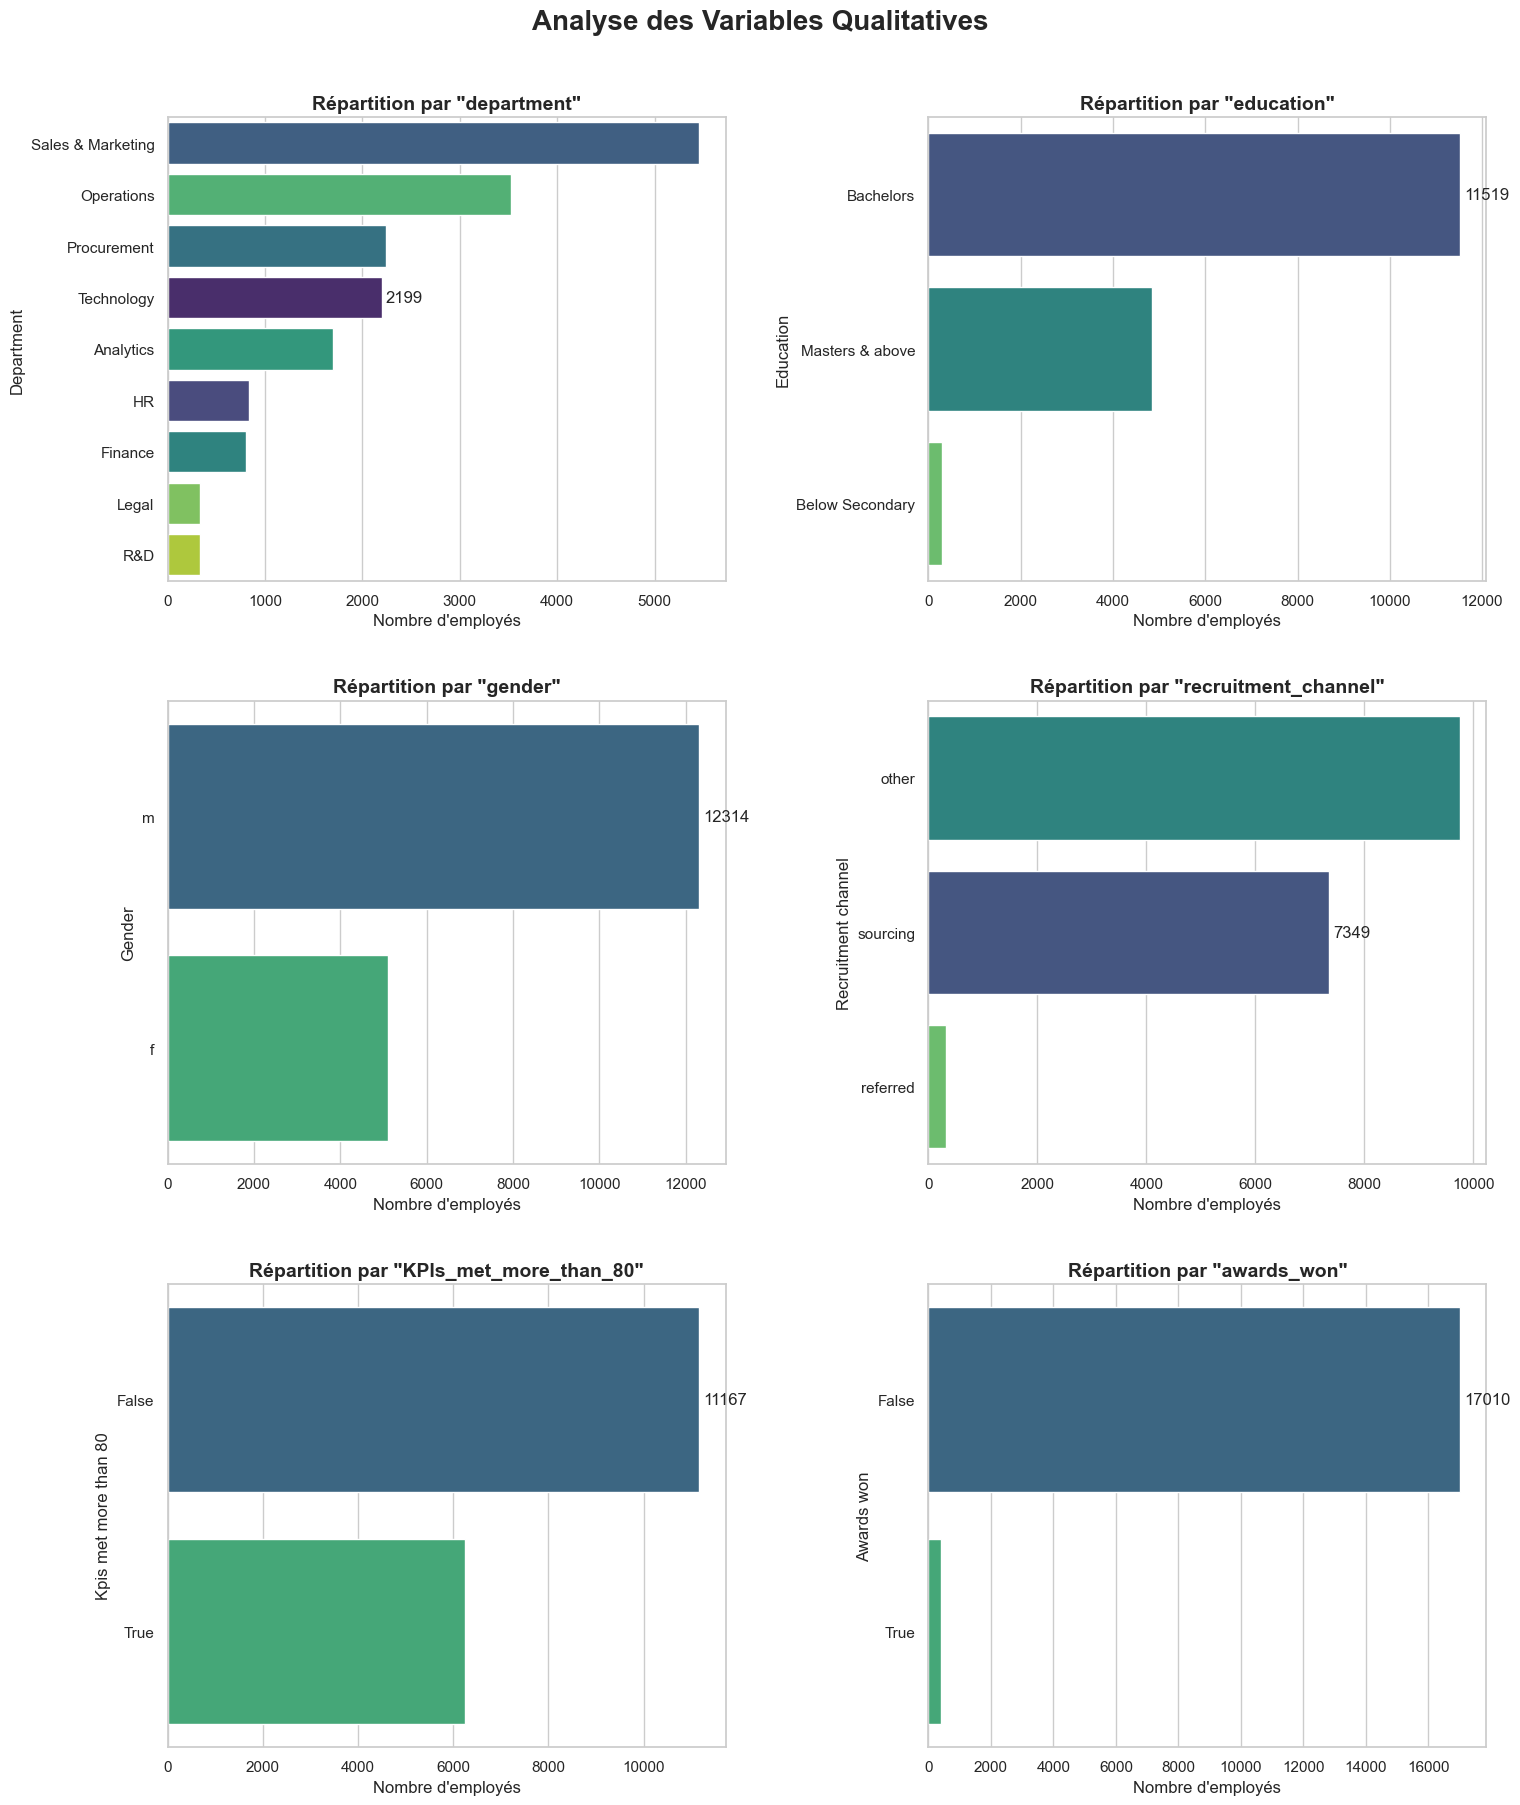

In [30]:
# 4. EDA - DISTRIBUTION OF QUALITATIVE VARIABLES (COUNT PLOTS)
# ------------------------------------------------------------------------------
print("\n--- Generating Count Plots for Qualitative Variables ---")
sns.set_theme(style="whitegrid", palette="pastel")
num_plots = len(colonnes_qualitatives)
num_cols = 2
num_rows = math.ceil(num_plots / num_cols)
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, num_rows * 6))
axes = axes.flatten()
for i, col in enumerate(colonnes_qualitatives):
    ax = axes[i]
    order = eda[col].value_counts().index
    sns.countplot(data=eda, y=col, hue=col, legend=False, ax=ax, order=order, palette='viridis')
    ax.set_title(f'Répartition par "{col}"', fontsize=14, fontweight='bold')
    ax.set_ylabel(col.replace('_', ' ').capitalize(), fontsize=12)
    ax.set_xlabel('Nombre d\'employés', fontsize=12)
    ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)
for j in range(num_plots, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout(pad=3.0)
fig.suptitle('Analyse des Variables Qualitatives', fontsize=20, fontweight='bold', y=1.02)
plt.show()


--- Generating Pie Charts for Proportional Analysis ---


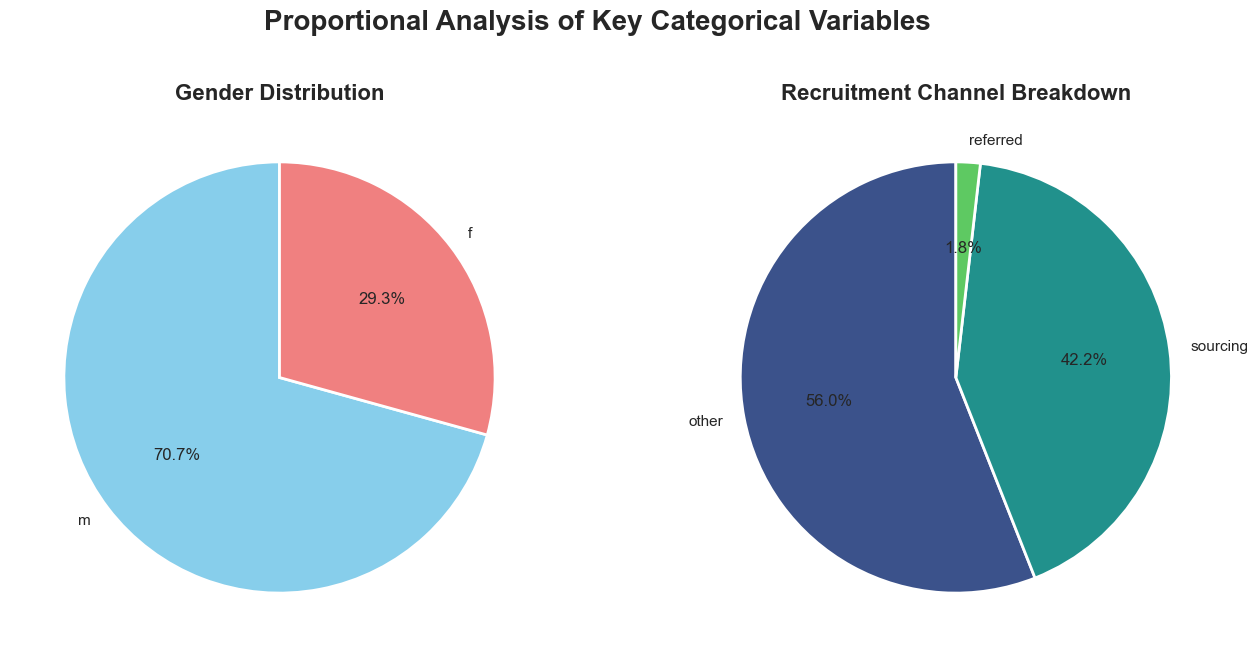

In [31]:
# 5. ADDITIONAL EDA - PROPORTIONAL ANALYSIS (PIE CHARTS)
# ------------------------------------------------------------------------------
print("\n--- Generating Pie Charts for Proportional Analysis ---")
plt.style.use('seaborn-v0_8-whitegrid')
gender_counts = eda['gender'].value_counts()
recruitment_counts = eda['recruitment_channel'].value_counts()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
ax1.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'], wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Gender Distribution', fontsize=16, fontweight='bold')
ax2.pie(recruitment_counts, labels=recruitment_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(recruitment_counts)), wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Recruitment Channel Breakdown', fontsize=16, fontweight='bold')
plt.suptitle('Proportional Analysis of Key Categorical Variables', fontsize=20, fontweight='bold', y=1.02)
plt.show()

Nombre de lignes avant suppression des outliers: 17417
Nombre de lignes après suppression des outliers: 16091


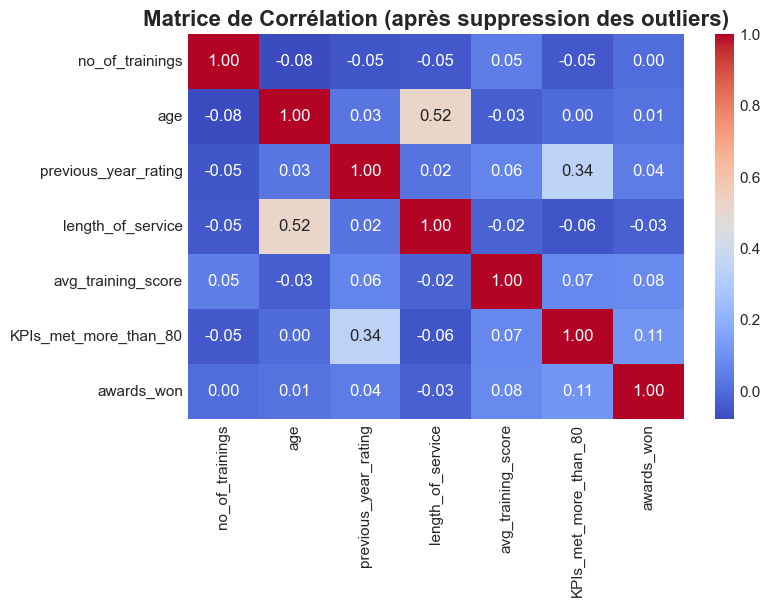

In [32]:
from sklearn.preprocessing import StandardScaler


print(f"Nombre de lignes avant suppression des outliers: {len(eda)}")
colonnes_numeriques= colonnes_quantitatives+["KPIs_met_more_than_80","awards_won"]

# --- 3. Supprimer les outliers pour chaque colonne numérique (Méthode IQR) ---
for col in colonnes_numeriques:
    # On ignore les colonnes avec peu de valeurs uniques (comme les ratings)
    if eda[col].nunique() < 10:
        continue

    Q1 = eda[col].quantile(0.25)
    Q3 = eda[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # On filtre le DataFrame pour ne garder que les valeurs dans les bornes
    eda= eda[(eda[col] >= lower_bound) & (eda[col] <= upper_bound)]

print(f"Nombre de lignes après suppression des outliers: {len(eda)}")


# --- 4. Calculer et visualiser la matrice de corrélation SUR LES DONNÉES NETTOYÉES ---
corr_matrix_cleaned = eda[colonnes_numeriques].corr()

plt.figure(figsize=(8,5))
sns.heatmap(
    corr_matrix_cleaned,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title('Matrice de Corrélation (après suppression des outliers)', fontsize=16, fontweight='bold')
plt.show()


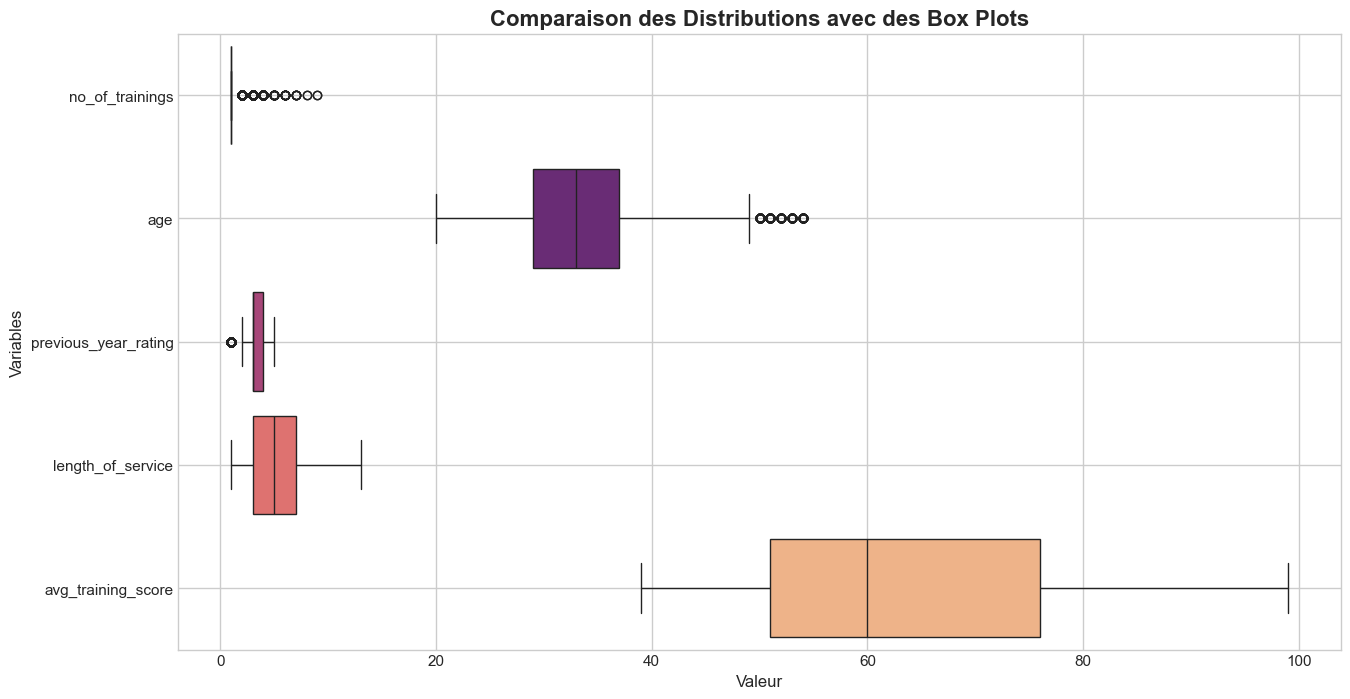

In [33]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=eda[colonnes_quantitatives], orient='h', palette='magma')


plt.title('Comparaison des Distributions avec des Box Plots', fontsize=16, fontweight='bold')
plt.xlabel('Valeur', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.grid(True)
plt.show()

In [34]:
# 9. FULL DATA PRE-PROCESSING FOR CLUSTERING
# ------------------------------------------------------------------------------
print("\n--- Starting Full Data Pre-processing ---")
df_preprocessed = eda.copy()
df_preprocessed=df_preprocessed.dropna()
df_preprocessed[["KPIs_met_more_than_80","awards_won"]] = df_preprocessed[["KPIs_met_more_than_80","awards_won"]].astype(int)


--- Starting Full Data Pre-processing ---


In [35]:
# Feature Engineering
df_preprocessed['trained_more_than_once'] = df_preprocessed['no_of_trainings'].apply(lambda x: 1 if x > 1 else 0)
df_preprocessed.drop('no_of_trainings', axis=1, inplace=True)


In [36]:
# Encoding
gender_map = {'m': 1, 'f': 0}
df_preprocessed['gender'] = df_preprocessed['gender'].map(gender_map)
education_map = {"Below Secondary": 0, "Bachelor's": 1, "Bachelors": 1, "Masters & above": 2}
df_preprocessed['education'] = df_preprocessed['education'].map(education_map)

In [37]:
# Scaling and One-Hot Encoding
numerical_cols = ['age', 'previous_year_rating', 'length_of_service', 'avg_training_score']
categorical_cols_ohe = ['department','recruitment_channel']
scaler = StandardScaler()
scaled_numerical_df = pd.DataFrame(scaler.fit_transform(df_preprocessed[numerical_cols]),
                                   columns=numerical_cols,
                                   index=df_preprocessed.index)
ohe_categorical_df = pd.get_dummies(df_preprocessed[categorical_cols_ohe], drop_first=True, dtype=int)
df_encoded_base = df_preprocessed[['gender', 'education', 'KPIs_met_more_than_80', 'awards_won', 'trained_more_than_once']]
df_final_processed = pd.concat([scaled_numerical_df, df_encoded_base, ohe_categorical_df], axis=1)

print("Pre-processing Complete. Final DataFrame dimensions:", df_final_processed.shape)

Pre-processing Complete. Final DataFrame dimensions: (14125, 19)


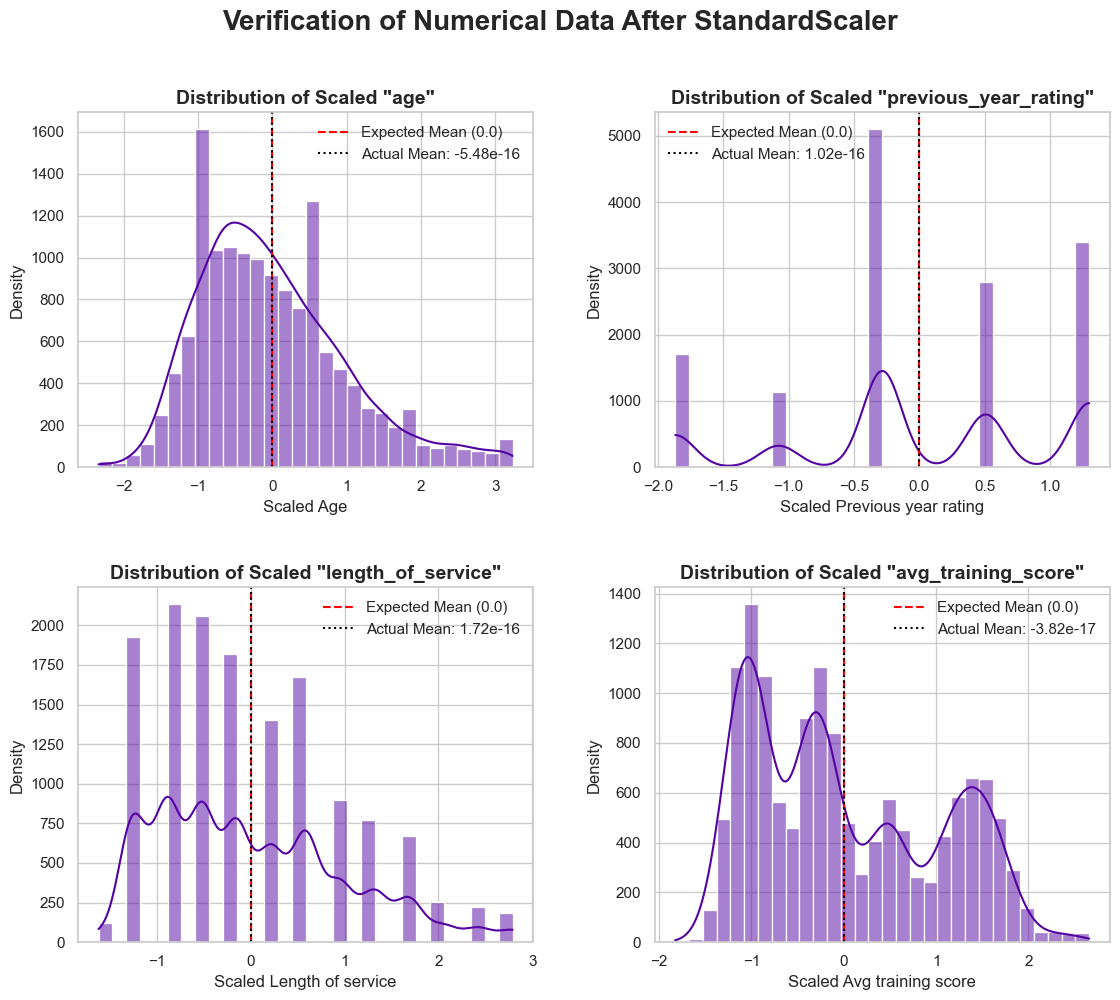

In [38]:
sns.set_theme(style="whitegrid", palette="plasma")
num_plots = len(numerical_cols)
num_cols = 2  # Adjusted to 2 columns for a cleaner look with 4 plots
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, num_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.histplot(data=scaled_numerical_df, x=col, kde=True, ax=ax, bins=30)

    # The mean of scaled data should be very close to 0
    mean_val = scaled_numerical_df[col].mean()
    ax.axvline(0, color='red', linestyle='--', label='Expected Mean (0.0)')
    ax.axvline(mean_val, color='black', linestyle=':', label=f'Actual Mean: {mean_val:.2e}')

    # Set titles and labels to reflect that the data is scaled
    ax.set_title(f'Distribution of Scaled "{col}"', fontsize=14, fontweight='bold')
    ax.set_xlabel(f'Scaled {col.replace("_", " ").capitalize()}', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend()

# Hide any unused subplots
for j in range(num_plots, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(pad=3.0)
fig.suptitle('Verification of Numerical Data After StandardScaler', fontsize=20, fontweight='bold', y=1.03)
plt.show()
# ==============================================================================

In [39]:
df_preprocessed["education"].value_counts()

education
1    9812
2    4145
0     168
Name: count, dtype: int64


--- Résumé des Transformations d'Encodage des Caractéristiques ---

[A] Résumé Quantitatif de l'Encodage One-Hot :
- La colonne 'department' avait 9 valeurs uniques, créant 8 nouvelles colonnes binaires.
- La colonne 'recruitment_channel' avait 3 valeurs uniques, créant 2 nouvelles colonnes binaires.

[B] Visualisation de l'État Final des Caractéristiques Encodées Manuellement :


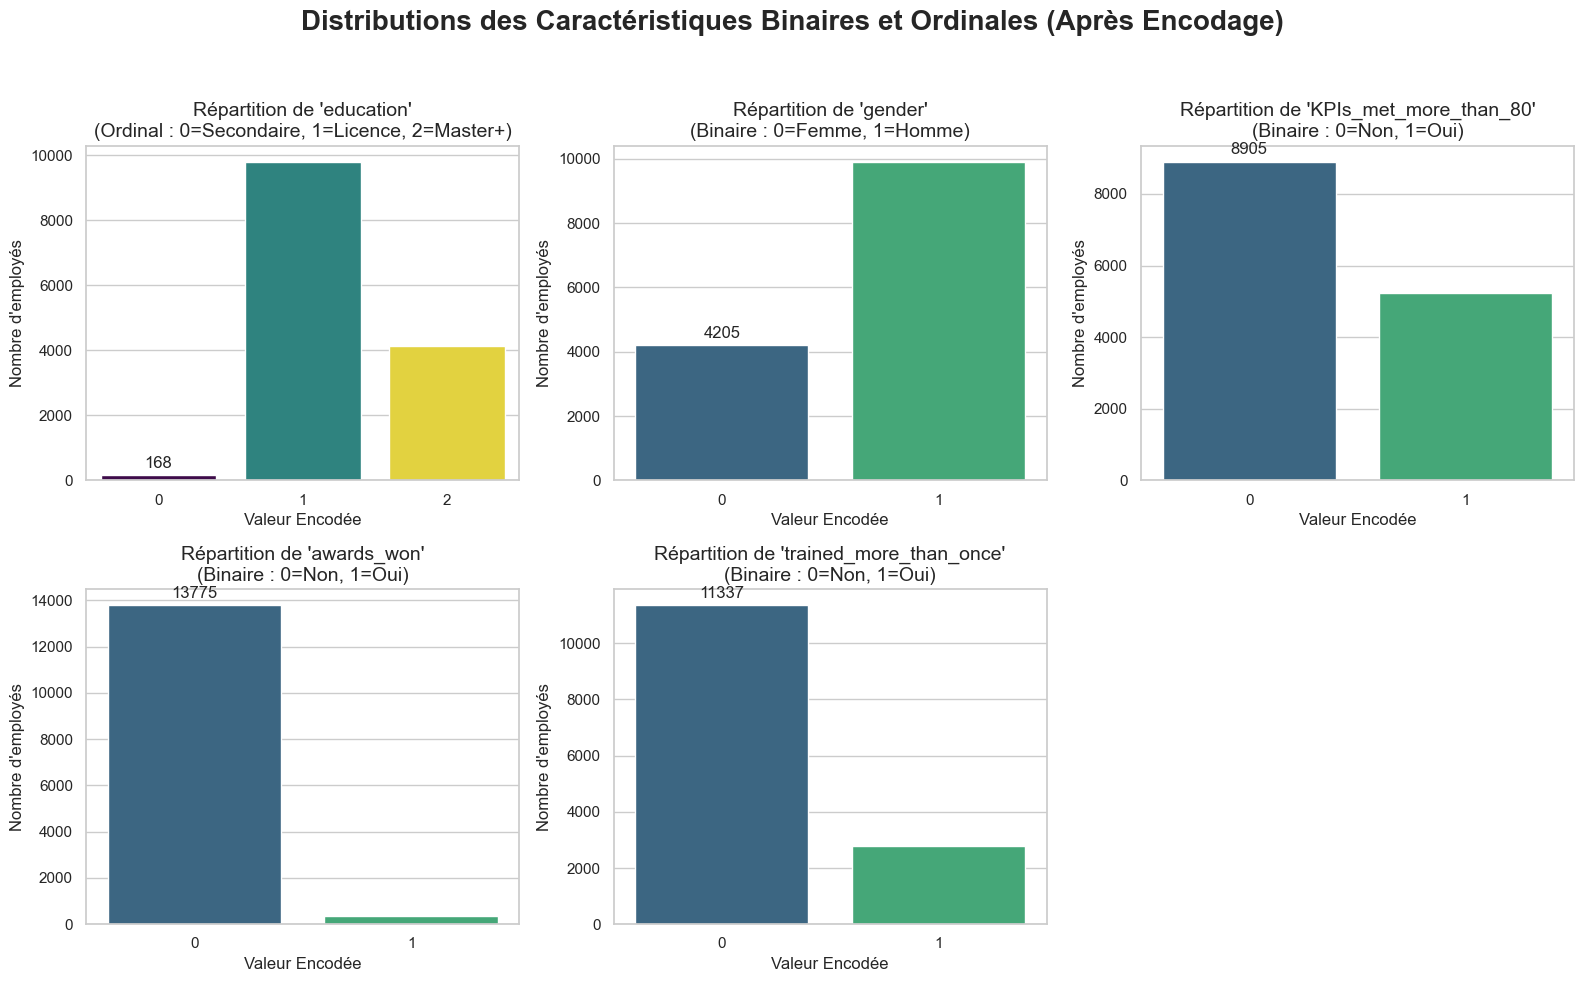

In [40]:
# ==============================================================================
#      RÉSUMÉ CONSOLIDÉ DE L'ENCODAGE (AVEC DISTINCTION BINAIRE/ORDINAL)
# ==============================================================================
print("\n--- Résumé des Transformations d'Encodage des Caractéristiques ---")

# --- PARTIE 1 : ANALYSE TEXTUELLE DE L'ENCODAGE ONE-HOT ---
print("\n[A] Résumé Quantitatif de l'Encodage One-Hot :")
categorical_cols_ohe = ['department','recruitment_channel']
for col in categorical_cols_ohe:
    num_unique = df_preprocessed[col].nunique()
    num_new_cols = num_unique - 1  # Car drop_first=True a été utilisé
    print(f"- La colonne '{col}' avait {num_unique} valeurs uniques, créant {num_new_cols} nouvelles colonnes binaires.")


# --- PARTIE 2 : ANALYSE VISUELLE DES CARACTÉRISTIQUES BINAIRES ET ORDINALES ---
print("\n[B] Visualisation de l'État Final des Caractéristiques Encodées Manuellement :")

# On sépare les types de variables pour plus de clarté
binary_cols = [
    'gender',
    'KPIs_met_more_than_80',
    'awards_won',
    'trained_more_than_once'
]
ordinal_cols = [
    'education'
]
# On les combine pour la boucle de traçage
cols_to_plot = ordinal_cols + binary_cols

# Créer une figure pour contenir les graphiques
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

fig.suptitle('Distributions des Caractéristiques Binaires et Ordinales (Après Encodage)', fontsize=20, fontweight='bold')

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    sns.countplot(
        data=df_preprocessed,
        x=col,
        ax=ax,
        palette='viridis',
        hue=col,
        legend=False
    )
    ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)

    # Ajouter des titres descriptifs pour le contexte
    title_text = f"Répartition de '{col}'"
    # Personnaliser le titre pour chaque type de variable
    if col in binary_cols:
        if col == 'gender':
            title_text += "\n(Binaire : 0=Femme, 1=Homme)"
        else:
            title_text += "\n(Binaire : 0=Non, 1=Oui)"
    elif col in ordinal_cols:
        if col == 'education':
            title_text += "\n(Ordinal : 0=Secondaire, 1=Licence, 2=Master+)"

    ax.set_title(title_text, fontsize=14)
    ax.set_xlabel('Valeur Encodée', fontsize=12)
    ax.set_ylabel("Nombre d'employés", fontsize=12)

# Cacher le dernier sous-graphique (inutilisé)
axes[-1].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
# ==============================================================================


--- Visualisation des Transformations de Feature Engineering ---


C:\Users\koudo\AppData\Local\Temp\ipykernel_10632\709588692.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(["Non (0)", "Oui (1)"])


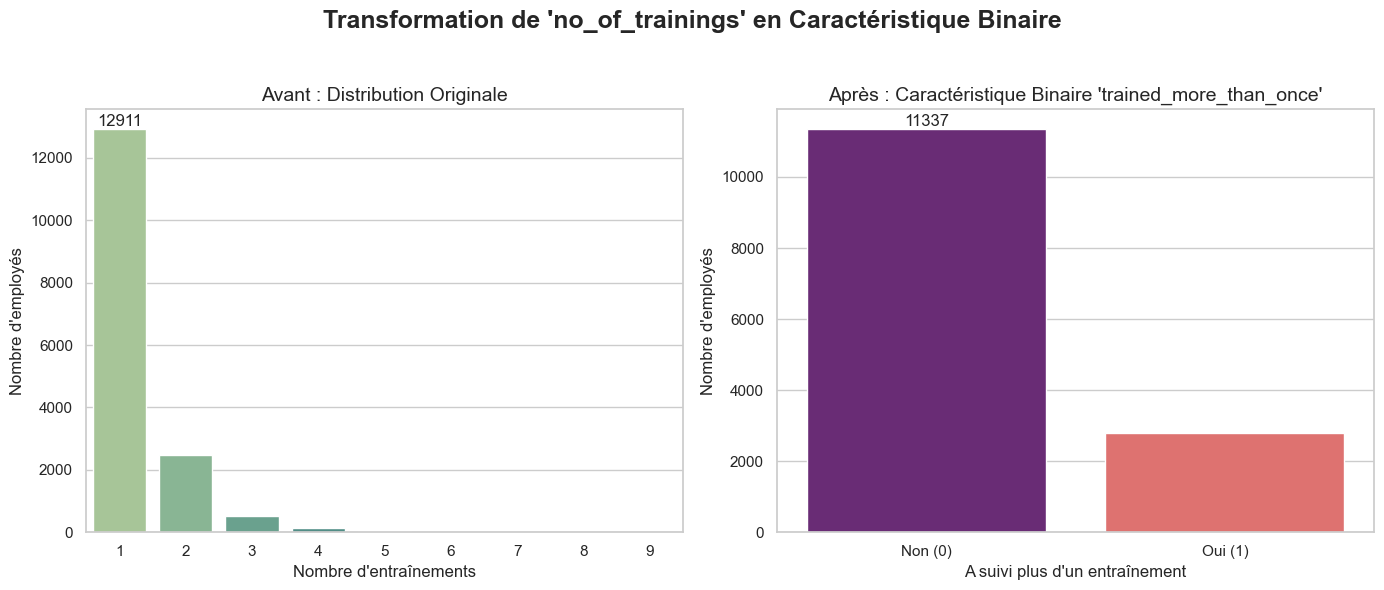

In [41]:
# ==============================================================================
#   NOUVELLE CELLULE : VISUALISATION DE L'INGÉNIERIE DES CARACTÉRISTIQUES
# ==============================================================================
print("\n--- Visualisation des Transformations de Feature Engineering ---")

# --- VISUALISATION 1 : Transformation de 'no_of_trainings' ---

# Créer une figure avec deux sous-graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Transformation de 'no_of_trainings' en Caractéristique Binaire", fontsize=18, fontweight='bold')

# Graphique de gauche : Avant la transformation
ax1 = axes[0]
sns.countplot(data=eda, x='no_of_trainings', ax=ax1, palette='crest', hue='no_of_trainings', legend=False)
ax1.set_title("Avant : Distribution Originale", fontsize=14)
ax1.set_xlabel("Nombre d'entraînements", fontsize=12)
ax1.set_ylabel("Nombre d'employés", fontsize=12)
ax1.bar_label(ax1.containers[0], fmt='%.0f')

# Graphique de droite : Après la transformation
ax2 = axes[1]
sns.countplot(data=df_preprocessed, x='trained_more_than_once', ax=ax2, palette='magma', hue='trained_more_than_once', legend=False)
ax2.set_title("Après : Caractéristique Binaire 'trained_more_than_once'", fontsize=14)
ax2.set_xlabel("A suivi plus d'un entraînement", fontsize=12)
ax2.set_ylabel("Nombre d'employés", fontsize=12)
# Rendre les étiquettes de l'axe X plus claires
ax2.set_xticklabels(["Non (0)", "Oui (1)"])
ax2.bar_label(ax2.containers[0], fmt='%.0f')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



# ==============================================================================

In [42]:
# 10. PCA - EXPLAINED VARIANCE ANALYSIS
# ------------------------------------------------------------------------------
print("\n--- Starting PCA Analysis ---")
data_for_pca = scaled_numerical_df
pca_full = PCA(random_state=42)
pca_full.fit(data_for_pca)
explained_variance = pca_full.explained_variance_ratio_



--- Starting PCA Analysis ---


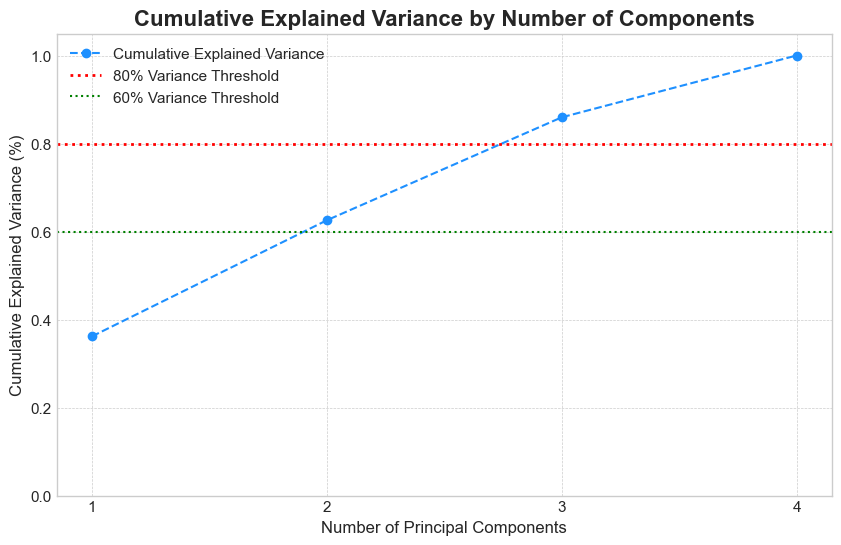

In [43]:
cumulative_variance = np.cumsum(explained_variance)
components = range(1, len(explained_variance) + 1)

# Create the Simplified Plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))
plt.plot(components, cumulative_variance, marker='o', linestyle='--', color='dodgerblue', label='Cumulative Explained Variance')
plt.axhline(y=0.80, color='red', linestyle=':', linewidth=2, label='80% Variance Threshold')
plt.axhline(y=0.60, color='green', linestyle=':', linewidth=1.5, label='60% Variance Threshold')
plt.title('Cumulative Explained Variance by Number of Components', fontsize=16, fontweight='bold')
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance (%)', fontsize=12)
plt.xticks(components)
plt.ylim(0, 1.05)
plt.legend(loc='best')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


--- Generating PCA Correlation Circle ---


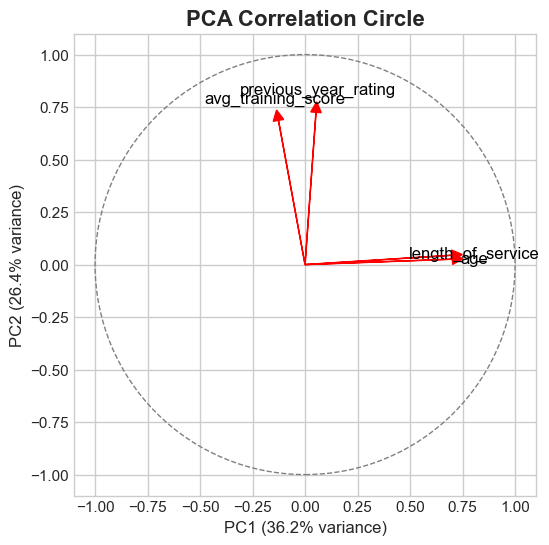

In [44]:
# 11. PCA - CORRELATION CIRCLE
# ------------------------------------------------------------------------------
print("\n--- Generating PCA Correlation Circle ---")
loadings = pca_full.components_.T
pc1_loadings = loadings[:, 0]
pc2_loadings = loadings[:, 1]
fig, ax = plt.subplots(figsize=(8, 6))
for i, feature in enumerate(numerical_cols):
    ax.arrow(0, 0, pc1_loadings[i], pc2_loadings[i], head_width=0.05, head_length=0.05, fc='red', ec='red')
    ax.text(pc1_loadings[i] * 1.15, pc2_loadings[i] * 1.15, feature, color='black', ha='center', va='center')
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax.add_artist(circle)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel(f'PC1 ({explained_variance[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_variance[1]:.1%} variance)', fontsize=12)
ax.set_title('PCA Correlation Circle', fontsize=16, fontweight='bold')
ax.grid(True)
ax.set_aspect('equal', adjustable='box')
plt.show()


In [45]:
# 12. PCA - SCATTER PLOT OF EMPLOYEES
# ------------------------------------------------------------------------------
print("\n--- Generating Final PCA Scatter Plot of Employees ---")
# Fit PCA with n_components=2 for the scatter plot
pca_2c = PCA(n_components=2, random_state=42)
pca_result = pca_2c.fit_transform(data_for_pca)
df_pca = pd.DataFrame(pca_result, columns=['PCA1_num', 'PCA2_num'], index=df_final_processed.index)
pca_plot_df = df_pca.join(eda['KPIs_met_more_than_80'])
pca_plot_df.dropna(inplace=True)


--- Generating Final PCA Scatter Plot of Employees ---


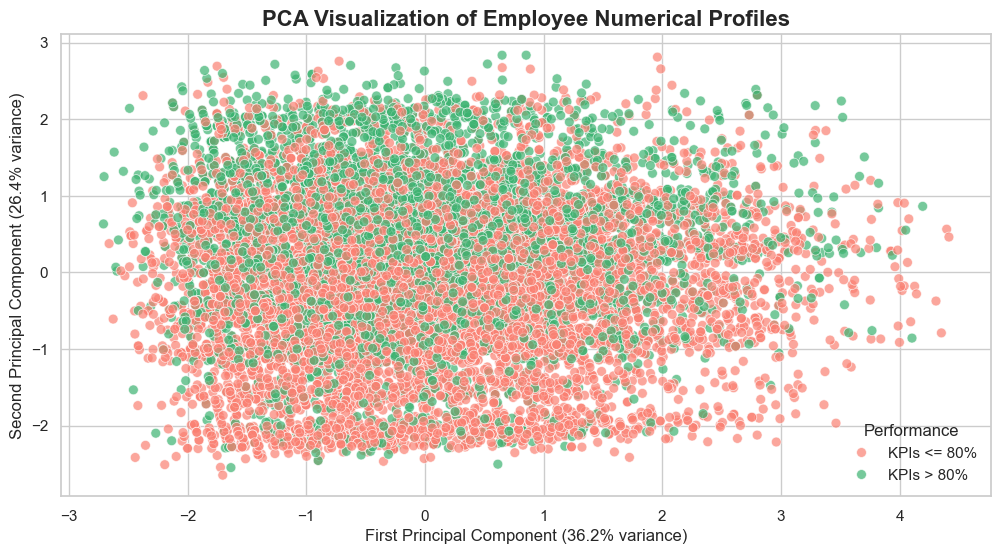


--- Analysis Complete ---


In [46]:
# Create the scatter plot
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
ax_pca = sns.scatterplot(
    x='PCA1_num',
    y='PCA2_num',
    hue='KPIs_met_more_than_80',
    data=pca_plot_df,
    palette={False: 'salmon', True: 'mediumseagreen'},
    alpha=0.7,
    s=50
)
explained_variance_2c = pca_2c.explained_variance_ratio_
plt.title('PCA Visualization of Employee Numerical Profiles', fontsize=16, fontweight='bold')
plt.xlabel(f'First Principal Component ({explained_variance_2c[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'Second Principal Component ({explained_variance_2c[1]:.1%} variance)', fontsize=12)
handles, labels = ax_pca.get_legend_handles_labels()
ax_pca.legend(handles=handles, labels=['KPIs <= 80%', 'KPIs > 80%'], title='Performance')
plt.show()

print("\n--- Analysis Complete ---")


In [78]:
df_preprocessed

,employee_id,department,region,education,gender,recruitment_channel,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score,trained_more_than_once
1,74430,HR,region_4,1,0,other,31,3.0,5,0,0,51,0
2,72255,Sales & Marketing,region_13,1,1,other,31,1.0,4,0,0,47,0
3,38562,Procurement,region_2,1,0,other,31,2.0,9,0,0,65,1
4,64486,Finance,region_29,1,1,sourcing,30,4.0,7,0,0,61,0
5,46232,Procurement,region_7,1,1,sourcing,36,3.0,2,0,0,68,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17412,64573,Technology,region_7,1,0,referred,30,5.0,6,1,0,81,1
17413,49584,HR,region_7,1,1,other,33,1.0,9,0,0,51,0
17414,49584,HR,region_7,1,1,other,33,1.0,9,0,0,51,0
17415,49584,HR,region_7,1,1,other,33,1.0,9,0,0,51,0


In [82]:
df_final_processed.columns

Index(['age', 'previous_year_rating', 'length_of_service',
       'avg_training_score', 'gender', 'education', 'KPIs_met_more_than_80',
       'awards_won', 'trained_more_than_once', 'department_Finance',
       'department_HR', 'department_Legal', 'department_Operations',
       'department_Procurement', 'department_R&D',
       'department_Sales & Marketing', 'department_Technology',
       'recruitment_channel_referred', 'recruitment_channel_sourcing'],
      dtype='object')

In [4]:
data_original = pd.read_csv('Uncleaned_employees_final_dataset.csv')
data_original=data_original.dropna()
data_original[["KPIs_met_more_than_80","awards_won"]] = data_original[["KPIs_met_more_than_80","awards_won"]].astype(int)
# Feature Engineering
data_original['trained_more_than_once'] = data_original['no_of_trainings'].apply(lambda x: 1 if x > 1 else 0)
data_original.drop('no_of_trainings', axis=1, inplace=True) 
# Encoding
gender_map = {'m': 1, 'f': 0}
data_original['gender'] = data_original['gender'].map(gender_map)


In [7]:
data_original

,employee_id,department,region,education,gender,recruitment_channel,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score,trained_more_than_once
1,74430,HR,region_4,Bachelors,0,other,31,3.0,5,0,0,51,0
2,72255,Sales & Marketing,region_13,Bachelors,1,other,31,1.0,4,0,0,47,0
3,38562,Procurement,region_2,Bachelors,0,other,31,2.0,9,0,0,65,1
4,64486,Finance,region_29,Bachelors,1,sourcing,30,4.0,7,0,0,61,0
5,46232,Procurement,region_7,Bachelors,1,sourcing,36,3.0,2,0,0,68,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17412,64573,Technology,region_7,Bachelors,0,referred,30,5.0,6,1,0,81,1
17413,49584,HR,region_7,Bachelors,1,other,33,1.0,9,0,0,51,0
17414,49584,HR,region_7,Bachelors,1,other,33,1.0,9,0,0,51,0
17415,49584,HR,region_7,Bachelors,1,other,33,1.0,9,0,0,51,0


In [9]:
data_original.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met_more_than_80', 'awards_won',
       'avg_training_score', 'trained_more_than_once'],
      dtype='object')

In [11]:
data_original=data_original.drop(columns=["region","employee_id"],axis=1)

In [13]:
data_original.columns

Index(['department', 'education', 'gender', 'recruitment_channel', 'age',
       'previous_year_rating', 'length_of_service', 'KPIs_met_more_than_80',
       'awards_won', 'avg_training_score', 'trained_more_than_once'],
      dtype='object')

In [15]:
data_original

,department,education,gender,recruitment_channel,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score,trained_more_than_once
1,HR,Bachelors,0,other,31,3.0,5,0,0,51,0
2,Sales & Marketing,Bachelors,1,other,31,1.0,4,0,0,47,0
3,Procurement,Bachelors,0,other,31,2.0,9,0,0,65,1
4,Finance,Bachelors,1,sourcing,30,4.0,7,0,0,61,0
5,Procurement,Bachelors,1,sourcing,36,3.0,2,0,0,68,0
...,...,...,...,...,...,...,...,...,...,...,...
17412,Technology,Bachelors,0,referred,30,5.0,6,1,0,81,1
17413,HR,Bachelors,1,other,33,1.0,9,0,0,51,0
17414,HR,Bachelors,1,other,33,1.0,9,0,0,51,0
17415,HR,Bachelors,1,other,33,1.0,9,0,0,51,0


In [17]:
colonnes_qualitatives_non_binaires=['department', 'education', 'recruitment_channel']
for col in colonnes_qualitatives_non_binaires:
     data_original[col]=data_original[col].astype(str)    

In [19]:
pip install gower-multiprocessing

Note: you may need to restart the kernel to use updated packages.


In [20]:
import importlib 
gower=importlib.import_module("gower_multiprocessing") 

In [21]:
dist=gower.gower_matrix(data_original)

In [45]:
from sklearn.cluster import HDBSCAN
# DBSCAN with lazy computation
db = HDBSCAN(cluster_selection_epsilon=0.1, min_samples=5,metric="precomputed")
db.fit(dist)

,min_cluster_size,5
,min_samples,5
,cluster_selection_epsilon,0.1
,max_cluster_size,None
,metric,'precomputed'
,metric_params,None
,alpha,1.0
,algorithm,'auto'
,leaf_size,40
,n_jobs,None
,cluster_selection_method,'eom'


In [29]:
from sklearn.manifold import TSNE
tsne=TSNE(n_components=2,init="random",metric="precomputed",random_state=42)
data_tsne=tsne.fit_transform(dist)


KeyboardInterrupt: 

In [47]:
!pip install umap-learn

import umap.umap_ as umap

reducer = umap.UMAP(n_neighbors=15,n_components=2, metric='precomputed', random_state=42)
X_umap = reducer.fit_transform(dist)

C:\Users\koudo\anaconda3\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
C:\Users\koudo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


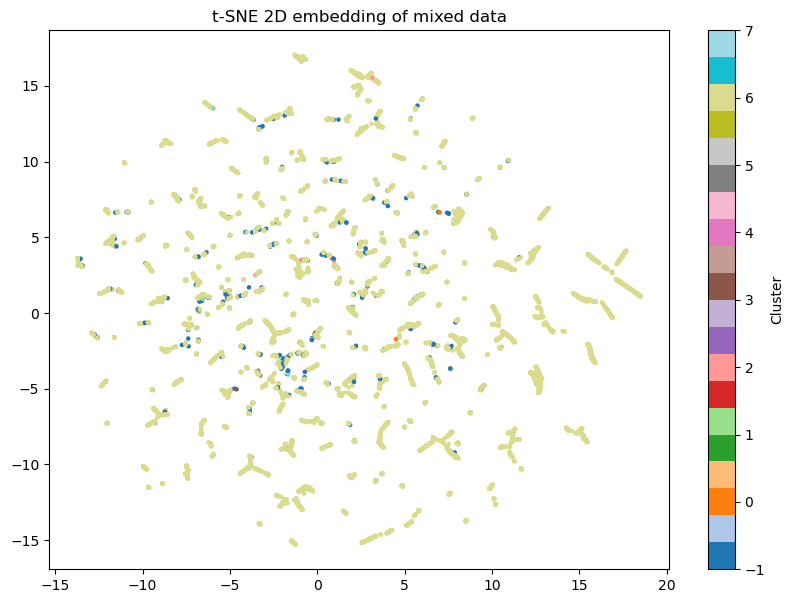

In [48]:
import matplotlib.pyplot as plt

labels =db.labels_  # -1 = noise

plt.figure(figsize=(10,7))
scatter = plt.scatter(X_umap[:,0],X_umap[:,1], c=labels, cmap='tab20', s=5)
plt.colorbar(scatter, label='Cluster')
plt.title("t-SNE 2D embedding of mixed data")
plt.show()

In [49]:
pd.Series(labels).value_counts()

 6    15045
-1      329
 2       11
 7       10
 4        7
 3        7
 5        5
 1        5
 0        5
Name: count, dtype: int64